## This notebook required GPU and should be run within ChromBPNet docker environment

In [2]:
## Load packages 
import tensorflow as tf
import numpy as np
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import pyBigWig
import tqdm
import sys
import pyfaidx
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
import shap
import glob
tf.compat.v1.disable_eager_execution()
from scipy.spatial.distance import jensenshannon
from numpy.linalg import norm
from scipy.stats import wasserstein_distance
import scipy.stats
import pandas as pd
import seaborn as sns
import matplotlib
import hdf5plugin
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import h5py
import pyBigWig
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
import deepdish as dd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf

## Functions

In [3]:
### Required functions 
def intersection(lst1, lst2):
    return list(set(lst1) & set(lst2))

In [4]:
def dna_to_one_hot(seqs):
    """
    Converts a list of DNA ("ACGT") sequences to one-hot encodings, where the
    position of 1s is ordered alphabetically by "ACGT". `seqs` must be a list
    of N strings, where every string is the same length L. Returns an N x L x 4
    NumPy array of one-hot encodings, in the same order as the input sequences.
    All bases will be converted to upper-case prior to performing the encoding.
    Any bases that are not "ACGT" will be given an encoding of all 0s.
    """
    seq_len = len(seqs[0])
    assert np.all(np.array([len(s) for s in seqs]) == seq_len)

    # Join all sequences together into one long string, all uppercase
    seq_concat = "".join(seqs).upper() + "ACGT"
    # Add one example of each base, so np.unique doesn't miss indices later

    one_hot_map = np.identity(5)[:, :-1].astype(np.int8)

    # Convert string into array of ASCII character codes;
    base_vals = np.frombuffer(bytearray(seq_concat, "utf8"), dtype=np.int8)

    # Anything that's not an A, C, G, or T gets assigned a higher code
    base_vals[~np.isin(base_vals, np.array([65, 67, 71, 84]))] = 85

    # Convert the codes into indices in [0, 4], in ascending order by code
    _, base_inds = np.unique(base_vals, return_inverse=True)

    # Get the one-hot encoding for those indices, and reshape back to separate
    return one_hot_map[base_inds[:-4]].reshape((len(seqs), seq_len, 4))

In [5]:
def softmax(x, temp=1):
    norm_x = x - np.mean(x,axis=1, keepdims=True)
    return np.exp(temp*norm_x)/np.sum(np.exp(temp*norm_x), axis=1, keepdims=True)

In [6]:
def generate_shap_dict(seqs, scores):
    print(seqs.shape, scores.shape)
    assert(seqs.shape==scores.shape)
    assert(seqs.shape[2]==4)

    # construct a dictionary for the raw shap scores and the
    # the projected shap scores
    # MODISCO workflow expects one hot sequences with shape (None,4,inputlen)
    d = {
            'raw': {'seq': np.transpose(seqs, (0, 2, 1))},
            'shap': {'seq': np.transpose(scores, (0, 2, 1))},
            'projected_shap': {'seq': np.transpose(seqs*scores, (0, 2, 1))}
        }

    return d

In [7]:
from deeplift.dinuc_shuffle import dinuc_shuffle

def combine_mult_and_diffref(mult, orig_inp, bg_data):
    to_return = []
    
    for l in [0]:
        projected_hypothetical_contribs = \
            np.zeros_like(bg_data[l]).astype("float")
        assert len(orig_inp[l].shape)==2
        
        # At each position in the input sequence, we iterate over the
        # one-hot encoding possibilities (eg: for genomic sequence, 
        # this is ACGT i.e. 1000, 0100, 0010 and 0001) and compute the
        # hypothetical difference-from-reference in each case. We then 
        # multiply the hypothetical differences-from-reference with 
        # the multipliers to get the hypothetical contributions. For 
        # each of the one-hot encoding possibilities, the hypothetical
        # contributions are then summed across the ACGT axis to 
        # estimate the total hypothetical contribution of each 
        # position. This per-position hypothetical contribution is then
        # assigned ("projected") onto whichever base was present in the
        # hypothetical sequence. The reason this is a fast estimate of
        # what the importance scores *would* look like if different 
        # bases were present in the underlying sequence is that the
        # multipliers are computed once using the original sequence, 
        # and are not computed again for each hypothetical sequence.
        for i in range(orig_inp[l].shape[-1]):
            hypothetical_input = np.zeros_like(orig_inp[l]).astype("float")
            hypothetical_input[:, i] = 1.0
            hypothetical_difference_from_reference = \
                (hypothetical_input[None, :, :] - bg_data[l])
            hypothetical_contribs = hypothetical_difference_from_reference * \
                                    mult[l]
            projected_hypothetical_contribs[:, :, i] = \
                np.sum(hypothetical_contribs, axis=-1) 
            
        to_return.append(np.mean(projected_hypothetical_contribs,axis=0))

    if len(orig_inp)>1:
        to_return.append(np.zeros_like(orig_inp[1]))
    
    return to_return


def shuffle_several_times(s):
    numshuffles=20
    if len(s)==2:
        return [np.array([dinuc_shuffle(s[0]) for i in range(numshuffles)]),
                np.array([s[1] for i in range(numshuffles)])]
    else:
        return [np.array([dinuc_shuffle(s[0]) for i in range(numshuffles)])]

In [8]:
def get_weightedsum_meannormed_logits(model):
    # Assumes the 0 task track is for profile
    # See Google slide deck for explanations
    # We meannorm as per section titled 
    # "Adjustments for Softmax Layers" in the DeepLIFT paper
    meannormed_logits = (model.outputs[0] - \
                         tf.reduce_mean(model.outputs[0], axis=1)[:, None])

    # 'stop_gradient' will prevent importance from being propagated
    # through this operation; we do this because we just want to treat
    # the post-softmax probabilities as 'weights' on the different 
    # logits, without having the network explain how the probabilities
    # themselves were derived. Could be worth contrasting explanations
    # derived with and without stop_gradient enabled...
    stopgrad_meannormed_logits = tf.stop_gradient(meannormed_logits)
    softmax_out = tf.nn.softmax(stopgrad_meannormed_logits, axis=1)
    
    # Weight the logits according to the softmax probabilities, take
    # the sum for each example. This mirrors what was done for the
    # bpnet paper.
    weightedsum_meannormed_logits = tf.reduce_sum(softmax_out * \
                                                  meannormed_logits,
                                                  axis=1)
    
    return weightedsum_meannormed_logits

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def ic_scale(pwm,background):
    odds_ratio = ((pwm+0.001)/(1.004))/(background[None,:])
    ic = ((np.log((pwm+0.001)/(1.004))/np.log(2))*pwm -\
            (np.log(background)*background/np.log(2))[None,:])
    return pwm*(np.sum(ic,axis=1)[:,None])


def plot_a(ax, base, left_edge, height, color):
    a_polygon_coords = [
        np.array([
           [0.0, 0.0],
           [0.5, 1.0],
           [0.5, 0.8],
           [0.2, 0.0],
        ]),
        np.array([
           [1.0, 0.0],
           [0.5, 1.0],
           [0.5, 0.8],
           [0.8, 0.0],
        ]),
        np.array([
           [0.225, 0.45],
           [0.775, 0.45],
           [0.85, 0.3],
           [0.15, 0.3],
        ])
    ]
    for polygon_coords in a_polygon_coords:
        ax.add_patch(matplotlib.patches.Polygon((np.array([1,height])[None,:]*polygon_coords
                                                 + np.array([left_edge,base])[None,:]),
                                                facecolor=color, edgecolor=color))


def plot_c(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=1.3, height=height,
                                            facecolor=color, edgecolor=color))
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=0.7*1.3, height=0.7*height,
                                            facecolor='white', edgecolor='white'))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+1, base], width=1.0, height=height,
                                            facecolor='white', edgecolor='white', fill=True))


def plot_g(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=1.3, height=height,
                                            facecolor=color, edgecolor=color))
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=0.7*1.3, height=0.7*height,
                                            facecolor='white', edgecolor='white'))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+1, base], width=1.0, height=height,
                                            facecolor='white', edgecolor='white', fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.825, base+0.085*height], width=0.174, height=0.415*height,
                                            facecolor=color, edgecolor=color, fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.625, base+0.35*height], width=0.374, height=0.15*height,
                                            facecolor=color, edgecolor=color, fill=True))


def plot_t(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.4, base],
                  width=0.2, height=height, facecolor=color, edgecolor=color, fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge, base+0.8*height],
                  width=1.0, height=0.2*height, facecolor=color, edgecolor=color, fill=True))

default_colors = {0:'green', 1:'blue', 2:'orange', 3:'red'}
default_plot_funcs = {0:plot_a, 1:plot_c, 2:plot_g, 3:plot_t}
def plot_weights_given_ax(ax, array,
                 height_padding_factor,
                 length_padding,
                 subticks_frequency,
                 highlight,
                 colors=default_colors,
                 plot_funcs=default_plot_funcs,
                 ylabel="",
                 ylim=None):
    if len(array.shape)==3:
        array = np.squeeze(array)
    assert len(array.shape)==2, array.shape
    if (array.shape[0]==4 and array.shape[1] != 4):
        array = array.transpose(1,0)
    assert array.shape[1]==4
    max_pos_height = 0.0
    min_neg_height = 0.0
    heights_at_positions = []
    depths_at_positions = []
    for i in range(array.shape[0]):
        #sort from smallest to highest magnitude
        acgt_vals = sorted(enumerate(array[i,:]), key=lambda x: abs(x[1]))
        positive_height_so_far = 0.0
        negative_height_so_far = 0.0
        for letter in acgt_vals:
            plot_func = plot_funcs[letter[0]]
            color=colors[letter[0]]
            if (letter[1] > 0):
                height_so_far = positive_height_so_far
                positive_height_so_far += letter[1]                
            else:
                height_so_far = negative_height_so_far
                negative_height_so_far += letter[1]
            plot_func(ax=ax, base=height_so_far, left_edge=i, height=letter[1], color=color)
        max_pos_height = max(max_pos_height, positive_height_so_far)
        min_neg_height = min(min_neg_height, negative_height_so_far)
        heights_at_positions.append(positive_height_so_far)
        depths_at_positions.append(negative_height_so_far)

    #now highlight any desired positions; the key of
    #the highlight dict should be the color
    for color in highlight:
        for start_pos, end_pos in highlight[color]:
            assert start_pos >= 0.0 and end_pos <= array.shape[0]
            min_depth = np.min(depths_at_positions[start_pos:end_pos])
            max_height = np.max(heights_at_positions[start_pos:end_pos])
            ax.add_patch(
                matplotlib.patches.Rectangle(xy=[start_pos,min_depth],
                    width=end_pos-start_pos,
                    height=max_height-min_depth,
                    edgecolor=color, fill=False))
            
    ax.set_xlim(-length_padding, array.shape[0]+length_padding)
    ax.xaxis.set_ticks(np.arange(0.0, array.shape[0]+1, subticks_frequency))

    if ylim is not None:
        # Use user-specified y-axis limits
        min_neg_height, max_pos_height = ylim
        assert min_neg_height <= 0
        assert max_pos_height >= 0

    height_padding = max(abs(min_neg_height)*(height_padding_factor),
                         abs(max_pos_height)*(height_padding_factor))
    ax.set_ylim(min_neg_height-height_padding, max_pos_height+height_padding)
    ax.set_ylabel(ylabel)
    ax.yaxis.label.set_fontsize(15)


def plot_weights(array,
                 figsize=(20,2),
                 height_padding_factor=0.2,
                 length_padding=1.0,
                 subticks_frequency=1.0,
                 colors=default_colors,
                 plot_funcs=default_plot_funcs,
                 highlight={},
                 ylabel="",
                 ylim=None,
                 filename=None,
                 return_fig=False):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111) 
    plot_weights_given_ax(ax=ax, array=array,
        height_padding_factor=height_padding_factor,
        length_padding=length_padding,
        subticks_frequency=subticks_frequency,
        colors=colors,
        plot_funcs=plot_funcs,
        highlight=highlight,
        ylabel=ylabel,
        ylim=ylim)
    plt.ylim(ylim)
    plt.savefig(filename,format="svg")

    if return_fig:
        return fig
    plt.show()

In [10]:
def calculate_correlations(array1, array2):
    correlations = np.zeros(array1.shape[0])
    
    for i in range(array1.shape[0]):
        corr, _ = pearsonr(array1[i], array2[i])
        correlations[i] = corr
    
    return correlations

In [11]:
from collections import Counter

def find_common_peaks(peaks):
    # Count occurrences of each peak
    peak_counts = Counter(peaks)

    # Filter peaks that occur at least twice
    common_peaks = [peak for peak, count in peak_counts.items() if count >= 2]

    return common_peaks


def merge_lists(lists):
    merged_list = []
    for lst in lists:
        merged_list.extend(lst)
    return merged_list

In [12]:
def generate_onehot_sequences(genome_fasta_path,peaks_with_summit):
    ref = pyfaidx.Fasta(genome_fasta_path)
    INPUT_LEN = 2114
    sequences = []
    buffer = 500
    for i,x in peaks_with_summit.iterrows():
        sequence = str(ref[x['peak_chrom']][((x['peak_start'] + x['summit']) - INPUT_LEN//2):((x['peak_start'] + x['summit']) + INPUT_LEN//2)])
        if len(sequence)==2114:
            sequence = sequence[:INPUT_LEN]
            sequences.append(sequence)
        else: 
            print(i)
    onehot_seq = []
    for i in range(len(sequences)):
        onehot_seq.append(dna_to_one_hot(sequences[i]).reshape(1,-1,4))

    onehot_seq = np.concatenate( onehot_seq, axis=0 )
    print(onehot_seq.shape)
    return onehot_seq

In [13]:
input_len = 2114
start = int(input_len/2 - 500)
end = int(input_len/2 + 500)
def compute_and_save_shap_scores(species_model,onehot_seq):
    model_profile_explainers = shap.explainers.deep.TFDeepExplainer(
    (species_model.input, get_weightedsum_meannormed_logits(species_model)),
    shuffle_several_times,
    combine_mult_and_diffref=combine_mult_and_diffref)
    profile_shap_scores = np.array(model_profile_explainers.shap_values(
    onehot_seq, progress_message=200))
    profile_shap_scores_dict = generate_shap_dict(onehot_seq, profile_shap_scores)
    profile_shap_scores_dict = profile_shap_scores_dict['projected_shap']['seq'][:]
    profile_shap_scores_dict = profile_shap_scores_dict.transpose(0,2,1)
    profile_shap_scores_dict = np.sum(profile_shap_scores_dict,axis=2)
    profile_shap_scores_dict = profile_shap_scores_dict[:,start:end]
    return profile_shap_scores_dict

In [14]:
def min_max_normalize_rows(df):
    # Copy the original DataFrame to avoid modifying the original data
    normalized_df = df.copy()
    
    # Iterate over each row
    for index, row in df.iterrows():
        # Calculate min and max values for the row
        min_value = row.min()
        max_value = row.max()
        
        # Perform min-max normalization for the row
        normalized_row = (row - min_value) / (max_value - min_value)
        
        # Update the normalized row in the new DataFrame
        normalized_df.loc[index] = normalized_row
    
    return normalized_df

def max_normalize_rows(df):
    # Copy the original DataFrame to avoid modifying the original data
    normalized_df = df.copy()
    
    # Iterate over each row
    for index, row in df.iterrows():
        # Calculate min and max values for the row
        min_value = row.min()
        max_value = row.max()
        
        # Perform max normalization for the row
        normalized_row = row / max_value
        
        # Update the normalized row in the new DataFrame
        normalized_df.loc[index] = normalized_row
    
    return normalized_df

### Loading models 

In [16]:
# Let's now load the two models and run the difference
with tf.keras.utils.CustomObjectScope({'multinomial_null':multinomial_nll, 'tf':tf}):
    mouse_neural = keras.models.load_model("../../mouse_zebrafish/mouse/models/allneural/fold_0/models/allneural_chrombpnet_nobias.h5")
    mouse_cardio = keras.models.load_model("../../mouse_zebrafish/mouse/models/cardiovascular/fold_0/models/chrombpnet_nobias.h5")
    mouse_endo = keras.models.load_model("../../mouse_zebrafish/mouse/models/endoderm/fold_0/models/chrombpnet_nobias.h5")

    zebra_neural = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/allneural/fold_0_1/models/all_neural_chrombpnet_nobias.h5")
    zebra_cardio = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/cardiovascular/fold_0/models/chrombpnet_nobias.h5")
    zebra_endo = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/endoderm/fold_0/models/chrombpnet_nobias.h5")

In [18]:
### Loading marker peaks for each cell type 
mouse_neural_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/mouse_da_peaks.tsv",sep="\t",header=None)
mouse_neural_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit'] 

mouse_cardio_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/cardiovascular_peaks_formatted.tsv",sep="\t",header=None)
mouse_cardio_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit'] 

mouse_endo_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/endoderm_peaks_formatted.tsv",sep="\t",header=None)
mouse_endo_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit'] 

zebra_neural_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/zebra_da_peaks_final.tsv",sep="\t",header=None)
zebra_neural_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit'] 

zebra_cardio_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/cardiovascular_peaks_formatted.tsv",sep="\t",header=None)
zebra_cardio_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit'] 

zebra_endo_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/endoderm_peaks_formatted.tsv",sep="\t",header=None)
zebra_endo_peaks.columns = ['peak_chrom','peak_start','peak_end','summit'] 


## Mouse and zebrafish onehot sequence

In [32]:
mouse_neural_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_neural_peaks)
mouse_cardio_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_cardio_peaks)
mouse_endo_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_endo_peaks)

zebra_neural_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_neural_peaks)
zebra_cardio_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_cardio_peaks)
zebra_endo_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_endo_peaks)

(12047, 2114, 4)
(7260, 2114, 4)
(2112, 2114, 4)
(6516, 2114, 4)
(3141, 2114, 4)
(3381, 2114, 4)


### Mouse neural peaks/ neural model correlation

In [22]:
mouse_neural_neural_pred = mouse_neural.predict(mouse_neural_onehot_seq)
zebra_neural_neural_pred = zebra_neural.predict(mouse_neural_onehot_seq)
zebra_cardio_neural_pred = zebra_cardio.predict(mouse_neural_onehot_seq)
zebra_endo_neural_pred = zebra_endo.predict(mouse_neural_onehot_seq)

mouse_neural_neural_logits, mouse_neural_neural_counts = mouse_neural_neural_pred
zebra_neural_neural_logits, zebra_neural_neural_counts = zebra_neural_neural_pred
zebra_cardio_neural_logits, zebra_cardio_neural_counts = zebra_cardio_neural_pred
zebra_endo_neural_logits, zebra_endo_neural_counts = zebra_endo_neural_pred

mouse_neural_neural_probs = softmax(mouse_neural_neural_logits)
zebra_neural_neural_probs = softmax(zebra_neural_neural_logits)
zebra_cardio_neural_probs = softmax(zebra_cardio_neural_logits)
zebra_endo_neural_probs = softmax(zebra_endo_neural_logits)

mouse_corr_neural_neural = calculate_correlations(mouse_neural_neural_probs, zebra_neural_neural_probs)
mouse_corr_cardio_neural = calculate_correlations(mouse_neural_neural_probs, zebra_cardio_neural_probs)
mouse_corr_endo_neural = calculate_correlations(mouse_neural_neural_probs, zebra_endo_neural_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-11-02 19:37:03.041513: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8100


In [23]:
mouse_neural_neural_SHAP = compute_and_save_shap_scores(mouse_neural, mouse_neural_onehot_seq)
zebra_neural_neural_SHAP = compute_and_save_shap_scores(zebra_neural, mouse_neural_onehot_seq)
zebra_cardio_neural_SHAP = compute_and_save_shap_scores(zebra_cardio, mouse_neural_onehot_seq)
zebra_endo_neural_SHAP = compute_and_save_shap_scores(zebra_endo, mouse_neural_onehot_seq)

mouse_corr_neural_neural_SHAP = calculate_correlations(mouse_neural_neural_SHAP, zebra_neural_neural_SHAP)
mouse_corr_cardio_neural_SHAP = calculate_correlations(mouse_neural_neural_SHAP, zebra_cardio_neural_SHAP)
mouse_corr_endo_neural_SHAP = calculate_correlations(mouse_neural_neural_SHAP, zebra_endo_neural_SHAP)


Done 0 examples of 12047
Done 200 examples of 12047
Done 400 examples of 12047
Done 600 examples of 12047
Done 800 examples of 12047
Done 1000 examples of 12047
Done 1200 examples of 12047
Done 1400 examples of 12047
Done 1600 examples of 12047
Done 1800 examples of 12047
Done 2000 examples of 12047
Done 2200 examples of 12047
Done 2400 examples of 12047
Done 2600 examples of 12047
Done 2800 examples of 12047
Done 3000 examples of 12047
Done 3200 examples of 12047
Done 3400 examples of 12047
Done 3600 examples of 12047
Done 3800 examples of 12047
Done 4000 examples of 12047
Done 4200 examples of 12047
Done 4400 examples of 12047
Done 4600 examples of 12047
Done 4800 examples of 12047
Done 5000 examples of 12047
Done 5200 examples of 12047
Done 5400 examples of 12047
Done 5600 examples of 12047
Done 5800 examples of 12047
Done 6000 examples of 12047
Done 6200 examples of 12047
Done 6400 examples of 12047
Done 6600 examples of 12047
Done 6800 examples of 12047
Done 7000 examples of 1204

In [24]:
df = {'corr_neural': mouse_corr_neural_neural,
      'corr_cardio': mouse_corr_cardio_neural,
      'corr_endo': mouse_corr_endo_neural,
      'corr_neural_SHAP': mouse_corr_neural_neural_SHAP,
      'corr_cardio_SHAP': mouse_corr_cardio_neural_SHAP,
      'corr_endo_SHAP': mouse_corr_endo_neural_SHAP}
mouse_neural_df = pd.DataFrame(df)
mouse_neural_df.to_csv("../../mouse_zebrafish/cross_species/mouse_neural_peaks_3models.csv", sep="\t",index=False) # change the path 

### Mouse cardio peaks/cardio model correlation

In [25]:
mouse_cardio_cardio_pred = mouse_cardio.predict(mouse_cardio_onehot_seq)
zebra_neural_cardio_pred = zebra_neural.predict(mouse_cardio_onehot_seq)
zebra_cardio_cardio_pred = zebra_cardio.predict(mouse_cardio_onehot_seq)
zebra_endo_cardio_pred = zebra_endo.predict(mouse_cardio_onehot_seq)

mouse_cardio_cardio_logits, mouse_cardio_cardio_counts = mouse_cardio_cardio_pred
zebra_neural_cardio_logits, zebra_neural_cardio_counts = zebra_neural_cardio_pred
zebra_cardio_cardio_logits, zebra_cardio_cardio_counts = zebra_cardio_cardio_pred
zebra_endo_cardio_logits, zebra_endo_cardio_counts = zebra_endo_cardio_pred

mouse_cardio_cardio_probs = softmax(mouse_cardio_cardio_logits)
zebra_neural_cardio_probs = softmax(zebra_neural_cardio_logits)
zebra_cardio_cardio_probs = softmax(zebra_cardio_cardio_logits)
zebra_endo_cardio_probs = softmax(zebra_endo_cardio_logits)

mouse_corr_neural_cardio = calculate_correlations(mouse_cardio_cardio_probs, zebra_neural_cardio_probs)
mouse_corr_cardio_cardio = calculate_correlations(mouse_cardio_cardio_probs, zebra_cardio_cardio_probs)
mouse_corr_endo_cardio = calculate_correlations(mouse_cardio_cardio_probs, zebra_endo_cardio_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


In [26]:
mouse_cardio_cardio_SHAP = compute_and_save_shap_scores(mouse_cardio, mouse_cardio_onehot_seq)
zebra_neural_cardio_SHAP = compute_and_save_shap_scores(zebra_neural, mouse_cardio_onehot_seq)
zebra_cardio_cardio_SHAP = compute_and_save_shap_scores(zebra_cardio, mouse_cardio_onehot_seq)
zebra_endo_cardio_SHAP = compute_and_save_shap_scores(zebra_endo, mouse_cardio_onehot_seq)

mouse_corr_neural_cardio_SHAP = calculate_correlations(mouse_cardio_cardio_SHAP, zebra_neural_cardio_SHAP)
mouse_corr_cardio_cardio_SHAP = calculate_correlations(mouse_cardio_cardio_SHAP, zebra_cardio_cardio_SHAP)
mouse_corr_endo_cardio_SHAP = calculate_correlations(mouse_cardio_cardio_SHAP, zebra_endo_cardio_SHAP)

Done 0 examples of 7260
Done 200 examples of 7260
Done 400 examples of 7260
Done 600 examples of 7260
Done 800 examples of 7260
Done 1000 examples of 7260
Done 1200 examples of 7260
Done 1400 examples of 7260
Done 1600 examples of 7260
Done 1800 examples of 7260
Done 2000 examples of 7260
Done 2200 examples of 7260
Done 2400 examples of 7260
Done 2600 examples of 7260
Done 2800 examples of 7260
Done 3000 examples of 7260
Done 3200 examples of 7260
Done 3400 examples of 7260
Done 3600 examples of 7260
Done 3800 examples of 7260
Done 4000 examples of 7260
Done 4200 examples of 7260
Done 4400 examples of 7260
Done 4600 examples of 7260
Done 4800 examples of 7260
Done 5000 examples of 7260
Done 5200 examples of 7260
Done 5400 examples of 7260
Done 5600 examples of 7260
Done 5800 examples of 7260
Done 6000 examples of 7260
Done 6200 examples of 7260
Done 6400 examples of 7260
Done 6600 examples of 7260
Done 6800 examples of 7260
Done 7000 examples of 7260
Done 7200 examples of 7260
(7260, 2

In [27]:
df = {'corr_neural': mouse_corr_neural_cardio,
      'corr_cardio': mouse_corr_cardio_cardio,
      'corr_endo': mouse_corr_endo_cardio,
      'corr_neural_SHAP': mouse_corr_neural_cardio_SHAP,
      'corr_cardio_SHAP': mouse_corr_cardio_cardio_SHAP,
      'corr_endo_SHAP': mouse_corr_endo_cardio_SHAP}
mouse_cardio_df = pd.DataFrame(df)
mouse_cardio_df.to_csv("../../mouse_zebrafish/cross_species/mouse_cardio_peaks_3models.csv", sep="\t",index=False) # change the path 

### Mouse endo peaks/ endo model correlation

In [28]:
mouse_endo_endo_pred = mouse_endo.predict(mouse_endo_onehot_seq)
zebra_neural_endo_pred = zebra_neural.predict(mouse_endo_onehot_seq)
zebra_cardio_endo_pred = zebra_cardio.predict(mouse_endo_onehot_seq)
zebra_endo_endo_pred = zebra_endo.predict(mouse_endo_onehot_seq)

mouse_endo_endo_logits, mouse_endo_endo_counts = mouse_endo_endo_pred
zebra_neural_endo_logits, zebra_neural_endo_counts = zebra_neural_endo_pred
zebra_cardio_endo_logits, zebra_cardio_endo_counts = zebra_cardio_endo_pred
zebra_endo_endo_logits, zebra_endo_endo_counts = zebra_endo_endo_pred

mouse_endo_endo_probs = softmax(mouse_endo_endo_logits)
zebra_neural_endo_probs = softmax(zebra_neural_endo_logits)
zebra_cardio_endo_probs = softmax(zebra_cardio_endo_logits)
zebra_endo_endo_probs = softmax(zebra_endo_endo_logits)

mouse_corr_neural_endo = calculate_correlations(mouse_endo_endo_probs, zebra_neural_endo_probs)
mouse_corr_cardio_endo = calculate_correlations(mouse_endo_endo_probs, zebra_cardio_endo_probs)
mouse_corr_endo_endo = calculate_correlations(mouse_endo_endo_probs, zebra_endo_endo_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


In [29]:
mouse_endo_endo_SHAP = compute_and_save_shap_scores(mouse_endo, mouse_endo_onehot_seq)
zebra_neural_endo_SHAP = compute_and_save_shap_scores(zebra_neural, mouse_endo_onehot_seq)
zebra_cardio_endo_SHAP = compute_and_save_shap_scores(zebra_cardio, mouse_endo_onehot_seq)
zebra_endo_endo_SHAP = compute_and_save_shap_scores(zebra_endo, mouse_endo_onehot_seq)

mouse_corr_neural_endo_SHAP = calculate_correlations(mouse_endo_endo_SHAP, zebra_neural_endo_SHAP)
mouse_corr_cardio_endo_SHAP = calculate_correlations(mouse_endo_endo_SHAP, zebra_cardio_endo_SHAP)
mouse_corr_endo_endo_SHAP = calculate_correlations(mouse_endo_endo_SHAP, zebra_endo_endo_SHAP)

Done 0 examples of 2112
Done 200 examples of 2112
Done 400 examples of 2112
Done 600 examples of 2112
Done 800 examples of 2112
Done 1000 examples of 2112
Done 1200 examples of 2112
Done 1400 examples of 2112
Done 1600 examples of 2112
Done 1800 examples of 2112
Done 2000 examples of 2112
(2112, 2114, 4) (2112, 2114, 4)
Done 0 examples of 2112
Done 200 examples of 2112
Done 400 examples of 2112
Done 600 examples of 2112
Done 800 examples of 2112
Done 1000 examples of 2112
Done 1200 examples of 2112
Done 1400 examples of 2112
Done 1600 examples of 2112
Done 1800 examples of 2112
Done 2000 examples of 2112
(2112, 2114, 4) (2112, 2114, 4)
Done 0 examples of 2112
Done 200 examples of 2112
Done 400 examples of 2112
Done 600 examples of 2112
Done 800 examples of 2112
Done 1000 examples of 2112
Done 1200 examples of 2112
Done 1400 examples of 2112
Done 1600 examples of 2112
Done 1800 examples of 2112
Done 2000 examples of 2112
(2112, 2114, 4) (2112, 2114, 4)
Done 0 examples of 2112
Done 200 e

In [30]:
df = {'corr_neural': mouse_corr_neural_endo,
      'corr_cardio': mouse_corr_cardio_endo,
      'corr_endo': mouse_corr_endo_endo,
      'corr_neural_SHAP': mouse_corr_neural_endo_SHAP,
      'corr_cardio_SHAP': mouse_corr_cardio_endo_SHAP,
      'corr_endo_SHAP': mouse_corr_endo_endo_SHAP}
mouse_endo_df = pd.DataFrame(df)
mouse_endo_df.to_csv("../../mouse_zebrafish/cross_species/mouse_endo_peaks_3models.csv", sep="\t",index=False) # change the path 

### Zebra neural peaks/ neural model correlation

In [33]:
zebra_neural_neural_pred = zebra_neural.predict(zebra_neural_onehot_seq)
mouse_neural_neural_pred = mouse_neural.predict(zebra_neural_onehot_seq)
mouse_cardio_neural_pred = mouse_cardio.predict(zebra_neural_onehot_seq)
mouse_endo_neural_pred = mouse_endo.predict(zebra_neural_onehot_seq)

zebra_neural_neural_logits, zebra_neural_neural_counts = zebra_neural_neural_pred
mouse_neural_neural_logits, mouse_neural_neural_counts = mouse_neural_neural_pred
mouse_cardio_neural_logits, mouse_cardio_neural_counts = mouse_cardio_neural_pred
mouse_endo_neural_logits, mouse_endo_neural_counts = mouse_endo_neural_pred

zebra_neural_neural_probs = softmax(zebra_neural_neural_logits)
mouse_neural_neural_probs = softmax(mouse_neural_neural_logits)
mouse_cardio_neural_probs = softmax(mouse_cardio_neural_logits)
mouse_endo_neural_probs = softmax(mouse_endo_neural_logits)

zebra_corr_neural_neural = calculate_correlations(zebra_neural_neural_probs, mouse_neural_neural_probs)
zebra_corr_cardio_neural = calculate_correlations(zebra_neural_neural_probs, mouse_cardio_neural_probs)
zebra_corr_endo_neural = calculate_correlations(zebra_neural_neural_probs, mouse_endo_neural_probs)


In [34]:
zebra_neural_neural_SHAP = compute_and_save_shap_scores(zebra_neural, zebra_neural_onehot_seq)
mouse_neural_neural_SHAP = compute_and_save_shap_scores(mouse_neural, zebra_neural_onehot_seq)
mouse_cardio_neural_SHAP = compute_and_save_shap_scores(mouse_cardio, zebra_neural_onehot_seq)
mouse_endo_neural_SHAP = compute_and_save_shap_scores(mouse_endo, zebra_neural_onehot_seq)

zebra_corr_neural_neural_SHAP = calculate_correlations(zebra_neural_neural_SHAP, mouse_neural_neural_SHAP)
zebra_corr_cardio_neural_SHAP = calculate_correlations(zebra_neural_neural_SHAP, mouse_cardio_neural_SHAP)
zebra_corr_endo_neural_SHAP = calculate_correlations(zebra_neural_neural_SHAP, mouse_endo_neural_SHAP)

Done 0 examples of 6516
Done 200 examples of 6516
Done 400 examples of 6516
Done 600 examples of 6516
Done 800 examples of 6516
Done 1000 examples of 6516
Done 1200 examples of 6516
Done 1400 examples of 6516
Done 1600 examples of 6516
Done 1800 examples of 6516
Done 2000 examples of 6516
Done 2200 examples of 6516
Done 2400 examples of 6516
Done 2600 examples of 6516
Done 2800 examples of 6516
Done 3000 examples of 6516
Done 3200 examples of 6516
Done 3400 examples of 6516
Done 3600 examples of 6516
Done 3800 examples of 6516
Done 4000 examples of 6516
Done 4200 examples of 6516
Done 4400 examples of 6516
Done 4600 examples of 6516
Done 4800 examples of 6516
Done 5000 examples of 6516
Done 5200 examples of 6516
Done 5400 examples of 6516
Done 5600 examples of 6516
Done 5800 examples of 6516
Done 6000 examples of 6516
Done 6200 examples of 6516
Done 6400 examples of 6516
(6516, 2114, 4) (6516, 2114, 4)
Done 0 examples of 6516
Done 200 examples of 6516
Done 400 examples of 6516
Done 600

In [35]:
df = {'corr_neural': zebra_corr_neural_neural,
      'corr_cardio': zebra_corr_cardio_neural,
      'corr_endo': zebra_corr_endo_neural,
      'corr_neural_SHAP': zebra_corr_neural_neural_SHAP,
      'corr_cardio_SHAP': zebra_corr_cardio_neural_SHAP,
      'corr_endo_SHAP': zebra_corr_endo_neural_SHAP}
zebra_neural_df = pd.DataFrame(df)
zebra_neural_df.to_csv("../../mouse_zebrafish/cross_species/zebra_neural_peaks_3models.csv", sep="\t",index=False) # change the path 

### zebra cardio peaks/cardio model correlation

In [36]:
zebra_cardio_cardio_pred = zebra_cardio.predict(zebra_cardio_onehot_seq)
mouse_neural_cardio_pred = mouse_neural.predict(zebra_cardio_onehot_seq)
mouse_cardio_cardio_pred = mouse_cardio.predict(zebra_cardio_onehot_seq)
mouse_endo_cardio_pred = mouse_endo.predict(zebra_cardio_onehot_seq)

zebra_cardio_cardio_logits, zebra_cardio_cardio_counts = zebra_cardio_cardio_pred
mouse_neural_cardio_logits, mouse_neural_cardio_counts = mouse_neural_cardio_pred
mouse_cardio_cardio_logits, mouse_cardio_cardio_counts = mouse_cardio_cardio_pred
mouse_endo_cardio_logits, mouse_endo_cardio_counts = mouse_endo_cardio_pred

zebra_cardio_cardio_probs = softmax(zebra_cardio_cardio_logits)
mouse_neural_cardio_probs = softmax(mouse_neural_cardio_logits)
mouse_cardio_cardio_probs = softmax(mouse_cardio_cardio_logits)
mouse_endo_cardio_probs = softmax(mouse_endo_cardio_logits)

zebra_corr_neural_cardio = calculate_correlations(zebra_cardio_cardio_probs, mouse_neural_cardio_probs)
zebra_corr_cardio_cardio = calculate_correlations(zebra_cardio_cardio_probs, mouse_cardio_cardio_probs)
zebra_corr_endo_cardio = calculate_correlations(zebra_cardio_cardio_probs, mouse_endo_cardio_probs)


In [37]:
zebra_cardio_cardio_SHAP = compute_and_save_shap_scores(zebra_cardio, zebra_cardio_onehot_seq)
mouse_neural_cardio_SHAP = compute_and_save_shap_scores(mouse_neural, zebra_cardio_onehot_seq)
mouse_cardio_cardio_SHAP = compute_and_save_shap_scores(mouse_cardio, zebra_cardio_onehot_seq)
mouse_endo_cardio_SHAP = compute_and_save_shap_scores(mouse_endo, zebra_cardio_onehot_seq)

zebra_corr_neural_cardio_SHAP = calculate_correlations(zebra_cardio_cardio_SHAP, mouse_neural_cardio_SHAP)
zebra_corr_cardio_cardio_SHAP = calculate_correlations(zebra_cardio_cardio_SHAP, mouse_cardio_cardio_SHAP)
zebra_corr_endo_cardio_SHAP = calculate_correlations(zebra_cardio_cardio_SHAP, mouse_endo_cardio_SHAP)

Done 0 examples of 3141
Done 200 examples of 3141
Done 400 examples of 3141
Done 600 examples of 3141
Done 800 examples of 3141
Done 1000 examples of 3141
Done 1200 examples of 3141
Done 1400 examples of 3141
Done 1600 examples of 3141
Done 1800 examples of 3141
Done 2000 examples of 3141
Done 2200 examples of 3141
Done 2400 examples of 3141
Done 2600 examples of 3141
Done 2800 examples of 3141
Done 3000 examples of 3141
(3141, 2114, 4) (3141, 2114, 4)
Done 0 examples of 3141
Done 200 examples of 3141
Done 400 examples of 3141
Done 600 examples of 3141
Done 800 examples of 3141
Done 1000 examples of 3141
Done 1200 examples of 3141
Done 1400 examples of 3141
Done 1600 examples of 3141
Done 1800 examples of 3141
Done 2000 examples of 3141
Done 2200 examples of 3141
Done 2400 examples of 3141
Done 2600 examples of 3141
Done 2800 examples of 3141
Done 3000 examples of 3141
(3141, 2114, 4) (3141, 2114, 4)
Done 0 examples of 3141
Done 200 examples of 3141
Done 400 examples of 3141
Done 600 e

In [38]:
df = {'corr_neural': zebra_corr_neural_cardio,
      'corr_cardio': zebra_corr_cardio_cardio,
      'corr_endo': zebra_corr_endo_cardio,
      'corr_neural_SHAP': zebra_corr_neural_cardio_SHAP,
      'corr_cardio_SHAP': zebra_corr_cardio_cardio_SHAP,
      'corr_endo_SHAP': zebra_corr_endo_cardio_SHAP}
zebra_cardio_df = pd.DataFrame(df)
zebra_cardio_df.to_csv("../../mouse_zebrafish/cross_species/zebra_cardio_peaks_3models.csv", sep="\t",index=False) # change the path 

### Zebra endo peaks/ endo model correlation

In [39]:
zebra_endo_endo_pred = zebra_endo.predict(zebra_endo_onehot_seq)
mouse_neural_endo_pred = mouse_neural.predict(zebra_endo_onehot_seq)
mouse_cardio_endo_pred = mouse_cardio.predict(zebra_endo_onehot_seq)
mouse_endo_endo_pred = mouse_endo.predict(zebra_endo_onehot_seq)

zebra_endo_endo_logits, zebra_endo_endo_counts = zebra_endo_endo_pred
mouse_neural_endo_logits, mouse_neural_endo_counts = mouse_neural_endo_pred
mouse_cardio_endo_logits, mouse_cardio_endo_counts = mouse_cardio_endo_pred
mouse_endo_endo_logits, mouse_endo_endo_counts = mouse_endo_endo_pred

zebra_endo_endo_probs = softmax(zebra_endo_endo_logits)
mouse_neural_endo_probs = softmax(mouse_neural_endo_logits)
mouse_cardio_endo_probs = softmax(mouse_cardio_endo_logits)
mouse_endo_endo_probs = softmax(mouse_endo_endo_logits)

zebra_corr_neural_endo = calculate_correlations(zebra_endo_endo_probs, mouse_neural_endo_probs)
zebra_corr_cardio_endo = calculate_correlations(zebra_endo_endo_probs, mouse_cardio_endo_probs)
zebra_corr_endo_endo = calculate_correlations(zebra_endo_endo_probs, mouse_endo_endo_probs)


In [40]:
zebra_endo_endo_SHAP = compute_and_save_shap_scores(zebra_endo, zebra_endo_onehot_seq)
mouse_neural_endo_SHAP = compute_and_save_shap_scores(mouse_neural, zebra_endo_onehot_seq)
mouse_cardio_endo_SHAP = compute_and_save_shap_scores(mouse_cardio, zebra_endo_onehot_seq)
mouse_endo_endo_SHAP = compute_and_save_shap_scores(mouse_endo, zebra_endo_onehot_seq)

zebra_corr_neural_endo_SHAP = calculate_correlations(zebra_endo_endo_SHAP, mouse_neural_endo_SHAP)
zebra_corr_cardio_endo_SHAP = calculate_correlations(zebra_endo_endo_SHAP, mouse_cardio_endo_SHAP)
zebra_corr_endo_endo_SHAP = calculate_correlations(zebra_endo_endo_SHAP, mouse_endo_endo_SHAP)

Done 0 examples of 3381
Done 200 examples of 3381
Done 400 examples of 3381
Done 600 examples of 3381
Done 800 examples of 3381
Done 1000 examples of 3381
Done 1200 examples of 3381
Done 1400 examples of 3381
Done 1600 examples of 3381
Done 1800 examples of 3381
Done 2000 examples of 3381
Done 2200 examples of 3381
Done 2400 examples of 3381
Done 2600 examples of 3381
Done 2800 examples of 3381
Done 3000 examples of 3381
Done 3200 examples of 3381
(3381, 2114, 4) (3381, 2114, 4)
Done 0 examples of 3381
Done 200 examples of 3381
Done 400 examples of 3381
Done 600 examples of 3381
Done 800 examples of 3381
Done 1000 examples of 3381
Done 1200 examples of 3381
Done 1400 examples of 3381
Done 1600 examples of 3381
Done 1800 examples of 3381
Done 2000 examples of 3381
Done 2200 examples of 3381
Done 2400 examples of 3381
Done 2600 examples of 3381
Done 2800 examples of 3381
Done 3000 examples of 3381
Done 3200 examples of 3381
(3381, 2114, 4) (3381, 2114, 4)
Done 0 examples of 3381
Done 200

In [41]:
df = {'corr_neural': zebra_corr_neural_endo,
      'corr_cardio': zebra_corr_cardio_endo,
      'corr_endo': zebra_corr_endo_endo,
      'corr_neural_SHAP': zebra_corr_neural_endo_SHAP,
      'corr_cardio_SHAP': zebra_corr_cardio_endo_SHAP,
      'corr_endo_SHAP': zebra_corr_endo_endo_SHAP}
zebra_endo_df = pd.DataFrame(df)
zebra_endo_df.to_csv("../../mouse_zebrafish/cross_species/zebra_endo_peaks_3models.csv", sep="\t",index=False) # change the path 

## Region specific model prediction 

In [32]:
# Let's now load the two models and run the difference
with tf.keras.utils.CustomObjectScope({'multinomial_null':multinomial_nll, 'tf':tf}):
    mouse_forebrain = keras.models.load_model("../../mouse_zebrafish/mouse/models/forebrain/fold_0/models/chrombpnet_nobias.h5")
    mouse_hindbrain = keras.models.load_model("../../mouse_zebrafish/mouse/models/hindbrain/fold_0/models/chrombpnet_nobias.h5")
    mouse_spinal_cord = keras.models.load_model("../../mouse_zebrafish/mouse/models/spinal_cord/fold_0/models/chrombpnet_nobias.h5")
    
    zebra_forebrain = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/forebrain/fold_0/models/chrombpnet_nobias.h5")
    zebra_hindbrain = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/hindbrain/fold_0/models/chrombpnet_nobias.h5")
    zebra_spinal_cord = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/spinal_cord/fold_0/models/chrombpnet_nobias.h5")
   

In [55]:
### Loading marker peaks for each cell type 
mouse_forebrain_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/mouse_da_peaks_forebrain_filtered.tsv",sep="\t",header=None)
mouse_forebrain_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']

mouse_hindbrain_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/mouse_da_peaks_hindbrain_filtered.tsv",sep="\t",header=None)
mouse_hindbrain_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']

mouse_spinal_cord_peaks = pd.read_csv("../../mouse_zebrafish/mouse/interpret/da_peaks/mouse_da_peaks_spinal_cord_filtered.tsv",sep="\t",header=None)
mouse_spinal_cord_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']


zebra_forebrain_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/zebra_da_peaks_forebrain_filtered.tsv",sep="\t",header=None)
zebra_forebrain_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']

zebra_hindbrain_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/zebra_da_peaks_hindbrain_filtered.tsv",sep="\t",header=None)
zebra_hindbrain_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']

zebra_spinal_cord_peaks = pd.read_csv("../../mouse_zebrafish/zebrafish/interpret/da_peaks/zebra_da_peaks_spinal_cord_filtered.tsv",sep="\t",header=None)
zebra_spinal_cord_peaks.columns = ['peak_chrom','peak_start','peak_end','V4','V5','V6','V7','V8','V9','summit']

In [57]:
mouse_forebrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_forebrain_peaks)
mouse_hindbrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_hindbrain_peaks)
mouse_spinal_cord_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_spinal_cord_peaks)

zebra_forebrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_forebrain_peaks)
zebra_hindbrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_hindbrain_peaks)
zebra_spinal_cord_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_spinal_cord_peaks)


(3038, 2114, 4)
(765, 2114, 4)
(3218, 2114, 4)
(1705, 2114, 4)
(1160, 2114, 4)
(920, 2114, 4)


### Mouse forebrain peaks

In [21]:
mouse_forebrain_pred = mouse_forebrain.predict(mouse_forebrain_onehot_seq)
zebra_forebrain_pred = zebra_forebrain.predict(mouse_forebrain_onehot_seq)
zebra_hindbrain_pred = zebra_hindbrain.predict(mouse_forebrain_onehot_seq)
zebra_spinal_cord_pred = zebra_spinal_cord.predict(mouse_forebrain_onehot_seq)

mouse_forebrain_logits, mouse_forebrain_counts = mouse_forebrain_pred
zebra_forebrain_logits, zebra_forebrain_counts = zebra_forebrain_pred
zebra_hindbrain_logits, zebra_hindbrain_counts = zebra_hindbrain_pred
zebra_spinal_cord_logits, zebra_spinal_cord_counts = zebra_spinal_cord_pred

mouse_forebrain_probs = softmax(mouse_forebrain_logits)
zebra_forebrain_probs = softmax(zebra_forebrain_logits)
zebra_hindbrain_probs = softmax(zebra_hindbrain_logits)
zebra_spinal_cord_probs = softmax(zebra_spinal_cord_logits)

corr_forebrain = calculate_correlations(mouse_forebrain_probs, zebra_forebrain_probs)
corr_hindbrain = calculate_correlations(mouse_forebrain_probs, zebra_hindbrain_probs)
corr_spinal_cord = calculate_correlations(mouse_forebrain_probs, zebra_spinal_cord_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-04-21 07:29:05.518148: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8100


In [22]:
mouse_forebrain_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
mouse_forebrain_df = pd.DataFrame(mouse_forebrain_df)

In [23]:
mouse_forebrain_SHAP = compute_and_save_shap_scores(mouse_forebrain, mouse_forebrain_onehot_seq)
zebra_forebrain_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_forebrain_onehot_seq)
zebra_hindbrain_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_forebrain_onehot_seq)
zebra_spinal_cord_SHAP = compute_and_save_shap_scores(zebra_spinal_cord, mouse_forebrain_onehot_seq)

corr_forebrain_SHAP = calculate_correlations(mouse_forebrain_SHAP, zebra_forebrain_SHAP)
corr_hindbrain_SHAP = calculate_correlations(mouse_forebrain_SHAP, zebra_hindbrain_SHAP)
corr_spinal_cord_SHAP = calculate_correlations(mouse_forebrain_SHAP, zebra_spinal_cord_SHAP)


Done 0 examples of 3038
Done 200 examples of 3038
Done 400 examples of 3038
Done 600 examples of 3038
Done 800 examples of 3038
Done 1000 examples of 3038
Done 1200 examples of 3038
Done 1400 examples of 3038
Done 1600 examples of 3038
Done 1800 examples of 3038
Done 2000 examples of 3038
Done 2200 examples of 3038
Done 2400 examples of 3038
Done 2600 examples of 3038
Done 2800 examples of 3038
Done 3000 examples of 3038
(3038, 2114, 4) (3038, 2114, 4)
Done 0 examples of 3038
Done 200 examples of 3038
Done 400 examples of 3038
Done 600 examples of 3038
Done 800 examples of 3038
Done 1000 examples of 3038
Done 1200 examples of 3038
Done 1400 examples of 3038
Done 1600 examples of 3038
Done 1800 examples of 3038
Done 2000 examples of 3038
Done 2200 examples of 3038
Done 2400 examples of 3038
Done 2600 examples of 3038
Done 2800 examples of 3038
Done 3000 examples of 3038
(3038, 2114, 4) (3038, 2114, 4)
Done 0 examples of 3038
Done 200 examples of 3038
Done 400 examples of 3038
Done 600 

In [26]:
mouse_forebrain_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
mouse_forebrain_SHAP_df = pd.DataFrame(mouse_forebrain_SHAP_df)
mouse_forebrain_all = pd.concat([mouse_forebrain_df,mouse_forebrain_SHAP_df],axis=1)
mouse_forebrain_all.to_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_forebrain_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Mouse Hindbrain peaks

In [39]:
mouse_hindbrain_pred = mouse_hindbrain.predict(mouse_hindbrain_onehot_seq)
zebra_hindbrain_pred = zebra_hindbrain.predict(mouse_hindbrain_onehot_seq)
zebra_forebrain_pred = zebra_forebrain.predict(mouse_hindbrain_onehot_seq)
zebra_spinal_cord_pred = zebra_spinal_cord.predict(mouse_hindbrain_onehot_seq)

mouse_hindbrain_logits, mouse_hindbrain_counts = mouse_hindbrain_pred
zebra_hindbrain_logits, zebra_hindbrain_counts = zebra_hindbrain_pred
zebra_forebrain_logits, zebra_forebrain_counts = zebra_forebrain_pred
zebra_spinal_cord_logits, zebra_spinal_cord_counts = zebra_spinal_cord_pred

mouse_hindbrain_probs = softmax(mouse_hindbrain_logits)
zebra_hindbrain_probs = softmax(zebra_hindbrain_logits)
zebra_forebrain_probs = softmax(zebra_forebrain_logits)
zebra_spinal_cord_probs = softmax(zebra_spinal_cord_logits)

corr_hindbrain = calculate_correlations(mouse_hindbrain_probs, zebra_hindbrain_probs)
corr_forebrain = calculate_correlations(mouse_hindbrain_probs, zebra_forebrain_probs)
corr_spinal_cord = calculate_correlations(mouse_hindbrain_probs, zebra_spinal_cord_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


In [40]:
mouse_hindbrain_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
mouse_hindbrain_df = pd.DataFrame(mouse_hindbrain_df)

In [29]:
mouse_hindbrain_SHAP = compute_and_save_shap_scores(mouse_hindbrain, mouse_hindbrain_onehot_seq)
zebra_hindbrain_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_hindbrain_onehot_seq)
zebra_forebrain_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_hindbrain_onehot_seq)
zebra_spinal_cord_SHAP = compute_and_save_shap_scores(zebra_spinal_cord, mouse_hindbrain_onehot_seq)

corr_hindbrain_SHAP = calculate_correlations(mouse_hindbrain_SHAP, zebra_hindbrain_SHAP)
corr_forebrain_SHAP = calculate_correlations(mouse_hindbrain_SHAP, zebra_forebrain_SHAP)
corr_spinal_cord_SHAP = calculate_correlations(mouse_hindbrain_SHAP, zebra_spinal_cord_SHAP)

Done 0 examples of 765
Done 200 examples of 765
Done 400 examples of 765
Done 600 examples of 765
(765, 2114, 4) (765, 2114, 4)
Done 0 examples of 765
Done 200 examples of 765
Done 400 examples of 765
Done 600 examples of 765
(765, 2114, 4) (765, 2114, 4)
Done 0 examples of 765
Done 200 examples of 765
Done 400 examples of 765
Done 600 examples of 765
(765, 2114, 4) (765, 2114, 4)
Done 0 examples of 765
Done 200 examples of 765
Done 400 examples of 765
Done 600 examples of 765
(765, 2114, 4) (765, 2114, 4)


In [41]:
mouse_hindbrain_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
mouse_hindbrain_SHAP_df = pd.DataFrame(mouse_hindbrain_SHAP_df)
mouse_hindbrain_all = pd.concat([mouse_hindbrain_df,mouse_hindbrain_SHAP_df],axis=1)
mouse_hindbrain_all.to_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_hindbrain_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Mouse Spinal cord peaks

In [45]:
mouse_spinal_cord_pred = mouse_spinal_cord.predict(mouse_spinal_cord_onehot_seq)
zebra_spinal_cord_pred = zebra_spinal_cord.predict(mouse_spinal_cord_onehot_seq)
zebra_hindbrain_pred = zebra_hindbrain.predict(mouse_spinal_cord_onehot_seq)
zebra_forebrain_pred = zebra_forebrain.predict(mouse_spinal_cord_onehot_seq)

mouse_spinal_cord_logits, mouse_spinal_cord_counts = mouse_spinal_cord_pred
zebra_spinal_cord_logits, zebra_spinal_cord_counts = zebra_spinal_cord_pred
zebra_hindbrain_logits, zebra_hindbrain_counts = zebra_hindbrain_pred
zebra_forebrain_logits, zebra_forebrain_counts = zebra_forebrain_pred

mouse_spinal_cord_probs = softmax(mouse_spinal_cord_logits)
zebra_spinal_cord_probs = softmax(zebra_spinal_cord_logits)
zebra_hindbrain_probs = softmax(zebra_hindbrain_logits)
zebra_forebrain_probs = softmax(zebra_forebrain_logits)

corr_spinal_cord = calculate_correlations(mouse_spinal_cord_probs, zebra_spinal_cord_probs)
corr_hindbrain = calculate_correlations(mouse_spinal_cord_probs, zebra_hindbrain_probs)
corr_forebrain = calculate_correlations(mouse_spinal_cord_probs, zebra_forebrain_probs)


In [46]:
mouse_spinal_cord_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
mouse_spinal_cord_df = pd.DataFrame(mouse_spinal_cord_df)

In [47]:
mouse_spinal_cord_SHAP = compute_and_save_shap_scores(mouse_spinal_cord, mouse_spinal_cord_onehot_seq)
zebra_spinal_cord_SHAP = compute_and_save_shap_scores(zebra_spinal_cord, mouse_spinal_cord_onehot_seq)
zebra_hindbrain_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_spinal_cord_onehot_seq)
zebra_forebrain_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_spinal_cord_onehot_seq)

corr_spinal_cord_SHAP = calculate_correlations(mouse_spinal_cord_SHAP, zebra_spinal_cord_SHAP)
corr_hindbrain_SHAP = calculate_correlations(mouse_spinal_cord_SHAP, zebra_hindbrain_SHAP)
corr_forebrain_SHAP = calculate_correlations(mouse_spinal_cord_SHAP, zebra_forebrain_SHAP)


Done 0 examples of 3218
Done 200 examples of 3218
Done 400 examples of 3218
Done 600 examples of 3218
Done 800 examples of 3218
Done 1000 examples of 3218
Done 1200 examples of 3218
Done 1400 examples of 3218
Done 1600 examples of 3218
Done 1800 examples of 3218
Done 2000 examples of 3218
Done 2200 examples of 3218
Done 2400 examples of 3218
Done 2600 examples of 3218
Done 2800 examples of 3218
Done 3000 examples of 3218
Done 3200 examples of 3218
(3218, 2114, 4) (3218, 2114, 4)
Done 0 examples of 3218
Done 200 examples of 3218
Done 400 examples of 3218
Done 600 examples of 3218
Done 800 examples of 3218
Done 1000 examples of 3218
Done 1200 examples of 3218
Done 1400 examples of 3218
Done 1600 examples of 3218
Done 1800 examples of 3218
Done 2000 examples of 3218
Done 2200 examples of 3218
Done 2400 examples of 3218
Done 2600 examples of 3218
Done 2800 examples of 3218
Done 3000 examples of 3218
Done 3200 examples of 3218
(3218, 2114, 4) (3218, 2114, 4)
Done 0 examples of 3218
Done 200

In [48]:
mouse_spinal_cord_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
mouse_spinal_cord_SHAP_df = pd.DataFrame(mouse_spinal_cord_SHAP_df)
mouse_spinal_cord_all = pd.concat([mouse_spinal_cord_df,mouse_spinal_cord_SHAP_df],axis=1)
mouse_spinal_cord_all.to_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_spinal_cord_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Zebrafish forebrain peaks

In [58]:
zebra_forebrain_pred = zebra_forebrain.predict(zebra_forebrain_onehot_seq)
mouse_forebrain_pred = mouse_forebrain.predict(zebra_forebrain_onehot_seq)
mouse_hindbrain_pred = mouse_hindbrain.predict(zebra_forebrain_onehot_seq)
mouse_spinal_cord_pred = mouse_spinal_cord.predict(zebra_forebrain_onehot_seq)

zebra_forebrain_logits, zebra_forebrain_counts = zebra_forebrain_pred
mouse_forebrain_logits, mouse_forebrain_counts = mouse_forebrain_pred
mouse_hindbrain_logits, mouse_hindbrain_counts = mouse_hindbrain_pred
mouse_spinal_cord_logits, mouse_spinal_cord_counts = mouse_spinal_cord_pred

zebra_forebrain_probs = softmax(zebra_forebrain_logits)
mouse_forebrain_probs = softmax(mouse_forebrain_logits)
mouse_hindbrain_probs = softmax(mouse_hindbrain_logits)
mouse_spinal_cord_probs = softmax(mouse_spinal_cord_logits)

corr_forebrain = calculate_correlations(zebra_forebrain_probs, mouse_forebrain_probs)
corr_hindbrain = calculate_correlations(zebra_forebrain_probs, mouse_hindbrain_probs)
corr_spinal_cord = calculate_correlations(zebra_forebrain_probs, mouse_spinal_cord_probs)


/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


In [59]:
zebra_forebrain_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
zebra_forebrain_df = pd.DataFrame(zebra_forebrain_df)

In [60]:
zebra_forebrain_SHAP = compute_and_save_shap_scores(zebra_forebrain, zebra_forebrain_onehot_seq)
mouse_forebrain_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_forebrain_onehot_seq)
mouse_hindbrain_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_forebrain_onehot_seq)
mouse_spinal_cord_SHAP = compute_and_save_shap_scores(mouse_spinal_cord, zebra_forebrain_onehot_seq)

corr_forebrain_SHAP = calculate_correlations(zebra_forebrain_SHAP, mouse_forebrain_SHAP)
corr_hindbrain_SHAP = calculate_correlations(zebra_forebrain_SHAP, mouse_hindbrain_SHAP)
corr_spinal_cord_SHAP = calculate_correlations(zebra_forebrain_SHAP, mouse_spinal_cord_SHAP)

Done 0 examples of 1705
Done 200 examples of 1705
Done 400 examples of 1705
Done 600 examples of 1705
Done 800 examples of 1705
Done 1000 examples of 1705
Done 1200 examples of 1705
Done 1400 examples of 1705
Done 1600 examples of 1705
(1705, 2114, 4) (1705, 2114, 4)
Done 0 examples of 1705
Done 200 examples of 1705
Done 400 examples of 1705
Done 600 examples of 1705
Done 800 examples of 1705
Done 1000 examples of 1705
Done 1200 examples of 1705
Done 1400 examples of 1705
Done 1600 examples of 1705
(1705, 2114, 4) (1705, 2114, 4)
Done 0 examples of 1705
Done 200 examples of 1705
Done 400 examples of 1705
Done 600 examples of 1705
Done 800 examples of 1705
Done 1000 examples of 1705
Done 1200 examples of 1705
Done 1400 examples of 1705
Done 1600 examples of 1705
(1705, 2114, 4) (1705, 2114, 4)
Done 0 examples of 1705
Done 200 examples of 1705
Done 400 examples of 1705
Done 600 examples of 1705
Done 800 examples of 1705
Done 1000 examples of 1705
Done 1200 examples of 1705
Done 1400 exam

In [61]:
zebra_forebrain_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
zebra_forebrain_SHAP_df = pd.DataFrame(zebra_forebrain_SHAP_df)
zebra_forebrain_all = pd.concat([zebra_forebrain_df,zebra_forebrain_SHAP_df],axis=1)
zebra_forebrain_all.to_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_forebrain_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Zebra Hindbrain peaks

In [62]:
zebra_hindbrain_pred = zebra_hindbrain.predict(zebra_hindbrain_onehot_seq)
mouse_hindbrain_pred = mouse_hindbrain.predict(zebra_hindbrain_onehot_seq)
mouse_forebrain_pred = mouse_forebrain.predict(zebra_hindbrain_onehot_seq)
mouse_spinal_cord_pred = mouse_spinal_cord.predict(zebra_hindbrain_onehot_seq)

zebra_hindbrain_logits, zebra_hindbrain_counts = zebra_hindbrain_pred
mouse_hindbrain_logits, mouse_hindbrain_counts = mouse_hindbrain_pred
mouse_forebrain_logits, mouse_forebrain_counts = mouse_forebrain_pred
mouse_spinal_cord_logits, mouse_spinal_cord_counts = mouse_spinal_cord_pred

zebra_hindbrain_probs = softmax(zebra_hindbrain_logits)
mouse_hindbrain_probs = softmax(mouse_hindbrain_logits)
mouse_forebrain_probs = softmax(mouse_forebrain_logits)
mouse_spinal_cord_probs = softmax(mouse_spinal_cord_logits)

corr_hindbrain = calculate_correlations(zebra_hindbrain_probs, mouse_hindbrain_probs)
corr_forebrain = calculate_correlations(zebra_hindbrain_probs, mouse_forebrain_probs)
corr_spinal_cord = calculate_correlations(zebra_hindbrain_probs, mouse_spinal_cord_probs)


In [63]:
zebra_hindbrain_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
zebra_hindbrain_df = pd.DataFrame(zebra_hindbrain_df)

In [64]:
zebra_hindbrain_SHAP = compute_and_save_shap_scores(zebra_hindbrain, zebra_hindbrain_onehot_seq)
mouse_hindbrain_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_hindbrain_onehot_seq)
mouse_forebrain_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_hindbrain_onehot_seq)
mouse_spinal_cord_SHAP = compute_and_save_shap_scores(mouse_spinal_cord, zebra_hindbrain_onehot_seq)

corr_hindbrain_SHAP = calculate_correlations(zebra_hindbrain_SHAP, mouse_hindbrain_SHAP)
corr_forebrain_SHAP = calculate_correlations(zebra_hindbrain_SHAP, mouse_forebrain_SHAP)
corr_spinal_cord_SHAP = calculate_correlations(zebra_hindbrain_SHAP, mouse_spinal_cord_SHAP)

Done 0 examples of 1160
Done 200 examples of 1160
Done 400 examples of 1160
Done 600 examples of 1160
Done 800 examples of 1160
Done 1000 examples of 1160
(1160, 2114, 4) (1160, 2114, 4)
Done 0 examples of 1160
Done 200 examples of 1160
Done 400 examples of 1160
Done 600 examples of 1160
Done 800 examples of 1160
Done 1000 examples of 1160
(1160, 2114, 4) (1160, 2114, 4)
Done 0 examples of 1160
Done 200 examples of 1160
Done 400 examples of 1160
Done 600 examples of 1160
Done 800 examples of 1160
Done 1000 examples of 1160
(1160, 2114, 4) (1160, 2114, 4)
Done 0 examples of 1160
Done 200 examples of 1160
Done 400 examples of 1160
Done 600 examples of 1160
Done 800 examples of 1160
Done 1000 examples of 1160
(1160, 2114, 4) (1160, 2114, 4)


In [65]:
zebra_hindbrain_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
zebra_hindbrain_SHAP_df = pd.DataFrame(zebra_hindbrain_SHAP_df)
zebra_hindbrain_all = pd.concat([zebra_hindbrain_df,zebra_hindbrain_SHAP_df],axis=1)
zebra_hindbrain_all.to_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_hindbrain_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Zebra Spinal cord peaks

In [66]:
zebra_spinal_cord_pred = zebra_spinal_cord.predict(zebra_spinal_cord_onehot_seq)
mouse_spinal_cord_pred = mouse_spinal_cord.predict(zebra_spinal_cord_onehot_seq)
mouse_hindbrain_pred = mouse_hindbrain.predict(zebra_spinal_cord_onehot_seq)
mouse_forebrain_pred = mouse_forebrain.predict(zebra_spinal_cord_onehot_seq)

zebra_spinal_cord_logits, zebra_spinal_cord_counts = zebra_spinal_cord_pred
mouse_spinal_cord_logits, mouse_spinal_cord_counts = mouse_spinal_cord_pred
mouse_hindbrain_logits, mouse_hindbrain_counts = mouse_hindbrain_pred
mouse_forebrain_logits, mouse_forebrain_counts = mouse_forebrain_pred

zebra_spinal_cord_probs = softmax(zebra_spinal_cord_logits)
mouse_spinal_cord_probs = softmax(mouse_spinal_cord_logits)
mouse_hindbrain_probs = softmax(mouse_hindbrain_logits)
mouse_forebrain_probs = softmax(mouse_forebrain_logits)

corr_spinal_cord = calculate_correlations(zebra_spinal_cord_probs, mouse_spinal_cord_probs)
corr_hindbrain = calculate_correlations(zebra_spinal_cord_probs, mouse_hindbrain_probs)
corr_forebrain = calculate_correlations(zebra_spinal_cord_probs, mouse_forebrain_probs)


In [67]:
zebra_spinal_cord_df = {'corr_forebrain': corr_forebrain, 'corr_hindbrain': corr_hindbrain, 'corr_spinal_cord': corr_spinal_cord}
zebra_spinal_cord_df = pd.DataFrame(zebra_spinal_cord_df)

In [68]:
zebra_spinal_cord_SHAP = compute_and_save_shap_scores(zebra_spinal_cord, zebra_spinal_cord_onehot_seq)
mouse_spinal_cord_SHAP = compute_and_save_shap_scores(mouse_spinal_cord, zebra_spinal_cord_onehot_seq)
mouse_hindbrain_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_spinal_cord_onehot_seq)
mouse_forebrain_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_spinal_cord_onehot_seq)

corr_spinal_cord_SHAP = calculate_correlations(zebra_spinal_cord_SHAP, mouse_spinal_cord_SHAP)
corr_hindbrain_SHAP = calculate_correlations(zebra_spinal_cord_SHAP, mouse_hindbrain_SHAP)
corr_forebrain_SHAP = calculate_correlations(zebra_spinal_cord_SHAP, mouse_forebrain_SHAP)


Done 0 examples of 920
Done 200 examples of 920
Done 400 examples of 920
Done 600 examples of 920
Done 800 examples of 920
(920, 2114, 4) (920, 2114, 4)
Done 0 examples of 920
Done 200 examples of 920
Done 400 examples of 920
Done 600 examples of 920
Done 800 examples of 920
(920, 2114, 4) (920, 2114, 4)
Done 0 examples of 920
Done 200 examples of 920
Done 400 examples of 920
Done 600 examples of 920
Done 800 examples of 920
(920, 2114, 4) (920, 2114, 4)
Done 0 examples of 920
Done 200 examples of 920
Done 400 examples of 920
Done 600 examples of 920
Done 800 examples of 920
(920, 2114, 4) (920, 2114, 4)


In [69]:
zebra_spinal_cord_SHAP_df = {'corr_forebrain_SHAP': corr_forebrain_SHAP, 
                       'corr_hindbrain_SHAP': corr_hindbrain_SHAP, 
                       'corr_spinal_cord_SHAP': corr_spinal_cord_SHAP}
zebra_spinal_cord_SHAP_df = pd.DataFrame(zebra_spinal_cord_SHAP_df)
zebra_spinal_cord_all = pd.concat([zebra_spinal_cord_df,zebra_spinal_cord_SHAP_df],axis=1)
zebra_spinal_cord_all.to_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_spinal_cord_withallinfo_filtered.csv", sep="\t",index=False) # change the path 

### Making brain regions heatmap

In [15]:
## Mouse regions 
mouse_forebrain_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_forebrain_withallinfo_filtered.csv", sep="\t")
mouse_hindbrain_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_hindbrain_withallinfo_filtered.csv", sep="\t")
mouse_spinal_cord_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_spinal_cord_withallinfo_filtered.csv", sep="\t")

In [16]:
mouse_forebrain_median = mouse_forebrain_filtered.iloc[:,[0,1,2]].median()
mouse_hindbrain_median = mouse_hindbrain_filtered.iloc[:,[0,1,2]].median()
mouse_spinal_cord_median = mouse_spinal_cord_filtered.iloc[:,[0,1,2]].median()


In [17]:
mouse_region_profile = pd.DataFrame([mouse_forebrain_median, mouse_hindbrain_median, mouse_spinal_cord_median])
mouse_region_profile.columns = [['corr_forebrain','corr_hindbrain','corr_spinal_cord']]

mouse_region_SHAP = pd.DataFrame([mouse_forebrain_SHAP_median, mouse_hindbrain_SHAP_median, mouse_spinal_cord_SHAP_median])
mouse_region_SHAP.columns = [['corr_forebrain_SHAP','corr_hindbrain_SHAP','corr_spinal_cord_SHAP']]


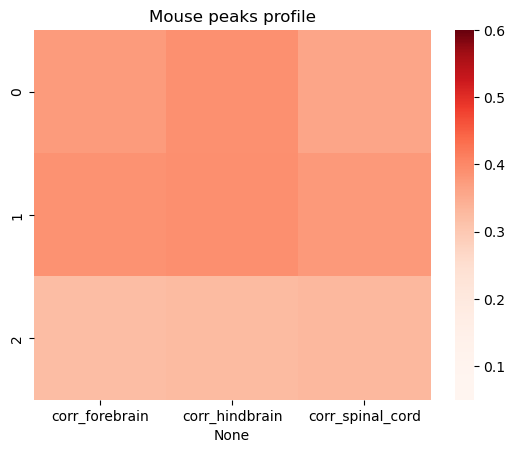

In [20]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )

sns.heatmap(mouse_region_profile, annot=False,cmap=custom_cmap,vmax=0.6,vmin=0.05)
plt.title("Mouse peaks profile")
plt.savefig("./plots/mouse_peaks_profile_brainregion.svg")

In [60]:
## Zebrafish regions 
zebra_forebrain_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_forebrain_withallinfo_filtered.csv", sep="\t")
zebra_hindbrain_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_hindbrain_withallinfo_filtered.csv", sep="\t")
zebra_spinal_cord_filtered = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_spinal_cord_withallinfo_filtered.csv", sep="\t")

In [61]:
zebra_forebrain_median = zebra_forebrain_filtered.iloc[:,[0,1,2]].median()
zebra_hindbrain_median = zebra_hindbrain_filtered.iloc[:,[0,1,2]].median()
zebra_spinal_cord_median = zebra_spinal_cord_filtered.iloc[:,[0,1,2]].median()


In [62]:
zebra_region_profile = pd.DataFrame([zebra_forebrain_median, zebra_hindbrain_median, zebra_spinal_cord_median])
zebra_region_profile.columns = [['corr_forebrain','corr_hindbrain','corr_spinal_cord']]




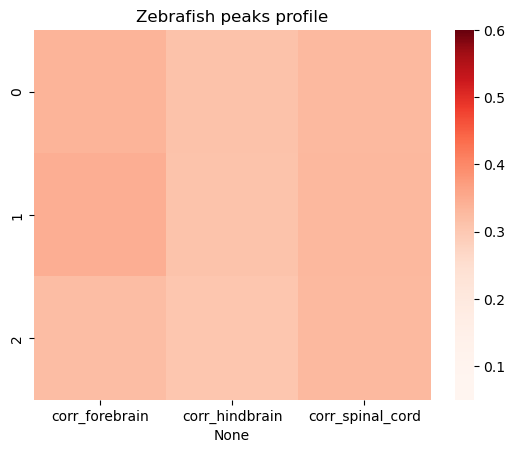

In [66]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )

sns.heatmap(zebra_region_profile, annot=False,cmap=custom_cmap,vmax=0.6,vmin=0.05)
plt.title("Zebrafish peaks profile")
plt.savefig("./plots/zebra_peaks_profile_brainregion.svg")

### Making cross-species Organ heatmap plot 

In [161]:
### Mouse peaks
mouse_neural = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_neural_peaks_3models_updated.csv",sep="\t")
mouse_cardio = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_cardio_peaks_3models_updated.csv",sep="\t")
mouse_endo = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_peaks/mouse_endo_peaks_3models_updated.csv",sep="\t")

In [157]:
mouse_neural_median = mouse_neural.iloc[:,[0,1,2]].median()
mouse_cardio_median = mouse_cardio.iloc[:,[0,1,2]].median()
mouse_endo_median = mouse_endo.iloc[:,[0,1,2]].median()

In [158]:
mouse_organ_profile = pd.DataFrame([mouse_neural_median, mouse_cardio_median, mouse_endo_median])
mouse_organ_profile.columns = [['corr_neural', 'corr_cardio','corr_endo']]


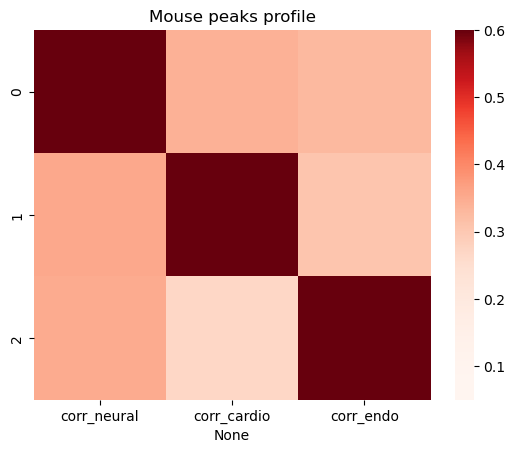

In [162]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )

sns.heatmap(mouse_organ_profile, annot=False,cmap=custom_cmap,vmax=0.6,vmin=0.05)
plt.title("Mouse peaks profile")
plt.savefig("./plots/mouse_peaks_profile_organ.svg")

In [98]:
### Zebrafish peaks 
zebra_neural = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_neural_peaks_3models_updated.csv",sep="\t")
zebra_cardio = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_cardio_peaks_3models_updated.csv",sep="\t")
zebra_endo = pd.read_csv("../../mouse_zebrafish/cross_species/zebra_peaks/zebra_endo_peaks_3models_updated.csv",sep="\t")

In [99]:
zebra_neural_median = zebra_neural.iloc[:,[0,1,2]].median()
zebra_cardio_median = zebra_cardio.iloc[:,[0,1,2]].median()
zebra_endo_median = zebra_endo.iloc[:,[0,1,2]].median()


In [100]:
zebra_organ_profile = pd.DataFrame([zebra_neural_median, zebra_cardio_median, zebra_endo_median])
zebra_organ_profile.columns = [['corr_neural', 'corr_cardio','corr_endo']]



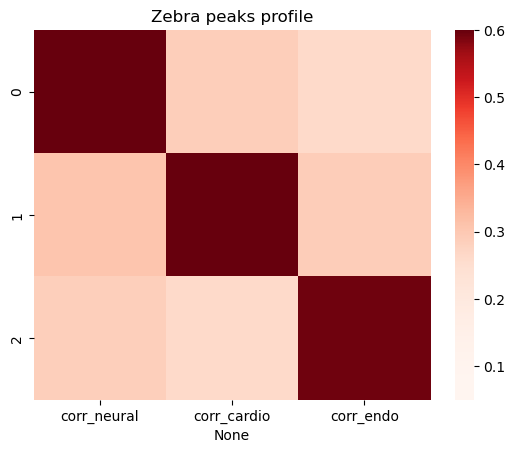

In [103]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )

sns.heatmap(zebra_organ_profile, annot=False,cmap=custom_cmap,vmax=0.6,vmin=0.05)
plt.title("Zebra peaks profile")
plt.savefig("./plots/zebra_peaks_profile_organ.svg")